In [1]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    roc_auc_score
)
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score

df = pd.read_csv('high_risk_pregnancy_realistic_2000 (1).csv')

In [2]:
import joblib

x_train_smote = joblib.load('x_train_smote.pkl')
y_train_smote = joblib.load('y_train_smote.pkl')
x_test_scaled = joblib.load('x_test_scaled.pkl')
y_test        = joblib.load('y_test.pkl')

In [3]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=20
)

In [4]:
rf_model.fit(x_train_smote, y_train_smote)

RandomForestClassifier(random_state=20)

In [5]:
rf_pred = rf_model.predict(x_test_scaled)

In [6]:
rf_prob = rf_model.predict_proba(x_test_scaled)[:, 1]
print(rf_prob)

[0.53 0.14 0.16 0.19 0.51 0.19 0.21 0.27 0.45 0.12 0.63 0.23 0.13 0.19
 0.27 0.14 0.17 0.55 0.17 0.21 0.34 0.35 0.43 0.21 0.57 0.25 0.21 0.17
 0.37 0.34 0.46 0.31 0.13 0.36 0.18 0.07 0.09 0.07 0.33 0.4  0.34 0.15
 0.17 0.44 0.27 0.24 0.35 0.21 0.12 0.13 0.2  0.09 0.11 0.51 0.29 0.42
 0.35 0.4  0.42 0.14 0.14 0.27 0.15 0.41 0.21 0.3  0.35 0.44 0.35 0.28
 0.22 0.46 0.28 0.16 0.31 0.27 0.13 0.33 0.35 0.28 0.26 0.28 0.13 0.16
 0.46 0.46 0.26 0.18 0.63 0.15 0.35 0.74 0.64 0.64 0.4  0.43 0.61 0.08
 0.29 0.15 0.25 0.16 0.37 0.3  0.27 0.34 0.22 0.48 0.55 0.19 0.51 0.48
 0.05 0.17 0.14 0.46 0.37 0.36 0.45 0.4  0.23 0.46 0.55 0.37 0.29 0.11
 0.42 0.29 0.2  0.18 0.13 0.36 0.23 0.26 0.32 0.32 0.32 0.15 0.14 0.34
 0.58 0.05 0.12 0.23 0.54 0.28 0.31 0.16 0.19 0.3  0.42 0.47 0.17 0.34
 0.21 0.21 0.05 0.31 0.32 0.33 0.11 0.44 0.2  0.28 0.18 0.23 0.43 0.31
 0.38 0.05 0.3  0.5  0.21 0.36 0.34 0.58 0.66 0.41 0.29 0.15 0.45 0.26
 0.12 0.2  0.13 0.37 0.33 0.38 0.2  0.47 0.2  0.34 0.2  0.14 0.23 0.16
 0.24 

In [7]:
rf_accuracy = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", round(rf_accuracy, 4))

Random Forest Accuracy: 0.787


In [8]:
print("Classification Report\n")

print(classification_report(y_test, rf_pred))

Classification Report

              precision    recall  f1-score   support

           0       0.84      0.92      0.88       330
           1       0.29      0.16      0.21        69

    accuracy                           0.79       399
   macro avg       0.56      0.54      0.54       399
weighted avg       0.74      0.79      0.76       399



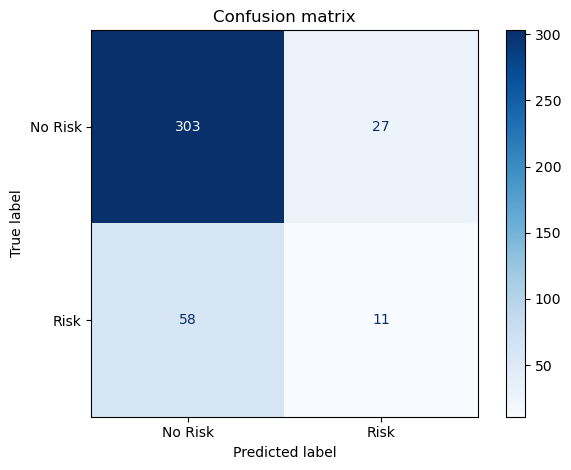

In [9]:
ConfusionMatrixDisplay.from_predictions(y_test,rf_pred,display_labels=['No Risk','Risk'],cmap='Blues')
plt.title("Confusion matrix")
plt.tight_layout()
plt.show()

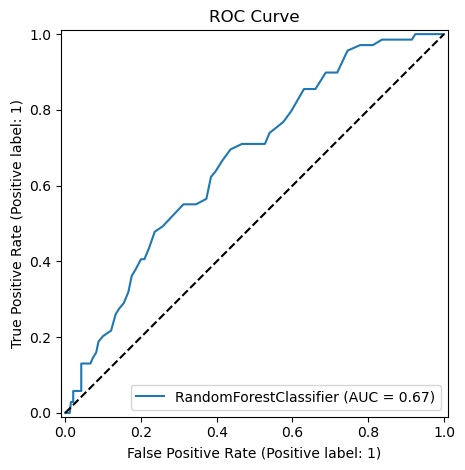

In [10]:
RocCurveDisplay.from_estimator(rf_model, x_test_scaled, y_test)
plt.title('ROC Curve')
plt.plot([0,1],[0,1],'k--')
plt.tight_layout()
plt.show()

In [11]:
print('ROC-AUC Score:', roc_auc_score(y_test, rf_prob).round(4))

ROC-AUC Score: 0.6664


In [12]:
X = df.drop("risk_class", axis=1)

feature_names = X.columns

print("Number of columns in df:", len(df.columns))

X = df.drop("risk_class", axis=1)
print("Number of features in X:", len(X.columns))

print("Number of feature importances:", len(rf_model.feature_importances_))


Number of columns in df: 24
Number of features in X: 23
Number of feature importances: 28


In [13]:
X = df.drop("risk_class", axis=1)
feature_names = X.columns 

In [14]:
n_importances = len(rf_model.feature_importances_)

In [15]:
if len(feature_names) == n_importances:
    labels = feature_names
else:
    labels = [f"feature_{i}" for i in range(n_importances)]

feature_importance = pd.DataFrame({
    "Feature": labels,
    "Importance": rf_model.feature_importances_,
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False,
)

print("\nFeature Importances:")
print(feature_importance.to_string(index=False))



Feature Importances:
   Feature  Importance
 feature_9    0.108164
feature_13    0.088017
feature_12    0.083001
feature_18    0.064172
feature_10    0.062512
feature_14    0.056455
 feature_6    0.055964
 feature_7    0.055182
 feature_8    0.052579
feature_11    0.052557
feature_16    0.048052
 feature_0    0.044727
feature_15    0.042848
 feature_1    0.024460
feature_24    0.021904
feature_21    0.021620
feature_25    0.016401
feature_17    0.016184
feature_19    0.013185
 feature_4    0.012149
 feature_2    0.011842
feature_22    0.011586
feature_23    0.009046
 feature_3    0.008028
feature_27    0.006814
feature_20    0.006134
feature_26    0.005693
 feature_5    0.000724


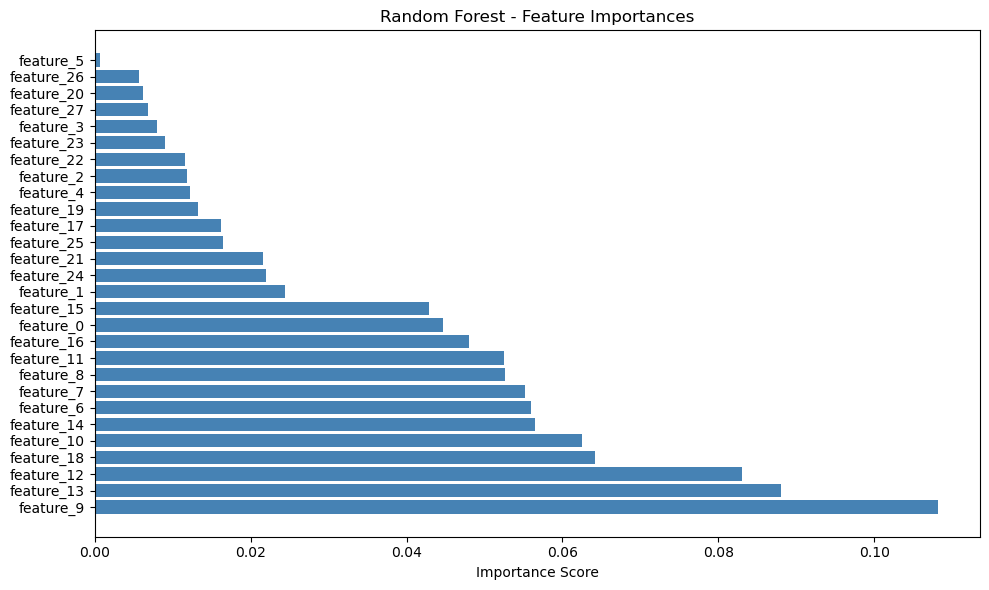

In [16]:
plt.figure(figsize=(10, 6))
plt.barh(feature_importance["Feature"], feature_importance["Importance"], color="steelblue")
plt.xlabel("Importance Score")
plt.title("Random Forest - Feature Importances")
plt.tight_layout()
plt.show()

In [17]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
}

grid_search = GridSearchCV(RandomForestClassifier(random_state=20),
                           param_grid, cv=5, scoring='roc_auc', n_jobs=-1)
grid_search.fit(x_train_smote, y_train_smote)


GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=20), n_jobs=-1,
             param_grid={'max_depth': [None, 10, 20],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [100, 200, 300]},
             scoring='roc_auc')

In [18]:
print("Best Params:", grid_search.best_params_)
best_model = grid_search.best_estimator_

Best Params: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 300}


In [19]:
cv_scores = cross_val_score(rf_model, x_train_smote, y_train_smote, cv=5, scoring='roc_auc')
print("CV ROC-AUC Scores:", cv_scores.round(4))
print("Mean:", cv_scores.mean().round(4), "| Std dev:", cv_scores.std().round(4))

CV ROC-AUC Scores: [0.9341 0.9855 0.9813 0.9851 0.9812]
Mean: 0.9734 | Std dev: 0.0198


In [20]:
joblib.dump(rf_model, 'random_forest_model.pkl')
print("Model saved.")

Model saved.


In [21]:
print("Classification Report\n")

print(classification_report(y_test, rf_pred))

Classification Report

              precision    recall  f1-score   support

           0       0.84      0.92      0.88       330
           1       0.29      0.16      0.21        69

    accuracy                           0.79       399
   macro avg       0.56      0.54      0.54       399
weighted avg       0.74      0.79      0.76       399

